IMPORTS

In [1]:
import pandas as pd
from pathlib import Path
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

Chargement dataset initial

In [2]:
def load_football_data(filename: str = "Euro-Football_2012-2023.csv") -> pd.DataFrame:

    # Chemins et URL
    DATASETS_PATH = Path("datasets")
    CSV_FILE_PATH = DATASETS_PATH / filename # Le chemin local pour le fichier CSV

    # L'URL RAW (Brute) pointant vers le nouveau fichier CSV sur GitHub

    URL_GITHUB_CSV = (
        "https://raw.githubusercontent.com/inesnft/Athlete-Performance-Prediction/main/Euro-Football_2012-2023.csv"
    )

    # 1. Vérification et téléchargement
    if not CSV_FILE_PATH.is_file():
        # Crée le répertoire 'datasets' si nécessaire
        DATASETS_PATH.mkdir(parents=True, exist_ok=True)

        print(f"Téléchargement de {filename} depuis GitHub...")
        # Téléchargement du fichier CSV
        urllib.request.urlretrieve(URL_GITHUB_CSV, CSV_FILE_PATH)
        print("Téléchargement terminé.")

    # 2. Chargement des données CSV
    try:
        # pd.read_csv lit le fichier téléchargé localement
        data_frame = pd.read_csv(CSV_FILE_PATH, sep=';')
        return data_frame
    except Exception as e:
        print(f"Erreur lors de la lecture du fichier CSV : {e}")
        return pd.DataFrame()

football_data = load_football_data()

# Vérification
if not football_data.empty:
    print("DataFrame 'football_data' chargé à partir du CSV.")
football_data.head()

DataFrame 'football_data' chargé à partir du CSV.


,id,Country,League,Div,Season,Date,HomeTeam,AwayTeam,Referee,FTHG,...,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
0,0,England,Premier League,E0,2012-2013,2012-08-18 00:00:00,Arsenal,Sunderland,C Foy,0.0,...,4.0,2.0,12.0,8.0,7.0,0.0,0.0,0.0,0.0,0.0
1,1,England,Premier League,E0,2012-2013,2012-08-18 00:00:00,Fulham,Norwich,M Oliver,5.0,...,9.0,2.0,12.0,11.0,6.0,3.0,0.0,0.0,0.0,0.0
2,2,England,Premier League,E0,2012-2013,2012-08-18 00:00:00,Newcastle,Tottenham,M Atkinson,2.0,...,4.0,6.0,12.0,8.0,3.0,5.0,2.0,2.0,0.0,0.0
3,3,England,Premier League,E0,2012-2013,2012-08-18 00:00:00,QPR,Swansea,L Probert,0.0,...,11.0,8.0,11.0,14.0,5.0,3.0,2.0,2.0,0.0,0.0
4,4,England,Premier League,E0,2012-2013,2012-08-18 00:00:00,Reading,Stoke,K Friend,1.0,...,3.0,3.0,9.0,14.0,4.0,3.0,2.0,4.0,0.0,1.0


In [3]:
football_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66147 entries, 0 to 66146
Data columns (total 27 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        66147 non-null  int64  
 1   Country   66147 non-null  object 
 2   League    66147 non-null  object 
 3   Div       66121 non-null  object 
 4   Season    66147 non-null  object 
 5   Date      66121 non-null  object 
 6   HomeTeam  66121 non-null  object 
 7   AwayTeam  66121 non-null  object 
 8   Referee   13620 non-null  object 
 9   FTHG      66119 non-null  float64
 10  FTAG      66119 non-null  float64
 11  FTR       66119 non-null  object 
 12  HTHG      66030 non-null  float64
 13  HTAG      66030 non-null  float64
 14  HTR       66030 non-null  object 
 15  HS        50116 non-null  float64
 16  AS        50116 non-null  float64
 17  HST       50116 non-null  float64
 18  AST       50116 non-null  float64
 19  HF        48778 non-null  float64
 20  AF        48778 non-null  fl

Plus de 10k matchs en Angleterre, on décide pour l'instant de créer un sous-dataset avec uniquement les matchs anglais permettant de réduire le nombre d'équipes ce qui pourra rendre le modèle meilleur en créant moins de colonnes avec OneHotEncoder.

In [4]:
data_eng=football_data[football_data['Country'] == 'England']
data_eng.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10748 entries, 0 to 66120
Data columns (total 27 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        10748 non-null  int64  
 1   Country   10748 non-null  object 
 2   League    10748 non-null  object 
 3   Div       10746 non-null  object 
 4   Season    10748 non-null  object 
 5   Date      10746 non-null  object 
 6   HomeTeam  10746 non-null  object 
 7   AwayTeam  10746 non-null  object 
 8   Referee   10193 non-null  object 
 9   FTHG      10746 non-null  float64
 10  FTAG      10746 non-null  float64
 11  FTR       10746 non-null  object 
 12  HTHG      10745 non-null  float64
 13  HTAG      10745 non-null  float64
 14  HTR       10745 non-null  object 
 15  HS        10745 non-null  float64
 16  AS        10745 non-null  float64
 17  HST       10745 non-null  float64
 18  AST       10745 non-null  float64
 19  HF        10745 non-null  float64
 20  AF        10745 non-null  float64

On supprime les lignes avec des caractéristiques nulles.

In [5]:
data_eng=data_eng.dropna()
data_eng.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10193 entries, 0 to 66120
Data columns (total 27 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        10193 non-null  int64  
 1   Country   10193 non-null  object 
 2   League    10193 non-null  object 
 3   Div       10193 non-null  object 
 4   Season    10193 non-null  object 
 5   Date      10193 non-null  object 
 6   HomeTeam  10193 non-null  object 
 7   AwayTeam  10193 non-null  object 
 8   Referee   10193 non-null  object 
 9   FTHG      10193 non-null  float64
 10  FTAG      10193 non-null  float64
 11  FTR       10193 non-null  object 
 12  HTHG      10193 non-null  float64
 13  HTAG      10193 non-null  float64
 14  HTR       10193 non-null  object 
 15  HS        10193 non-null  float64
 16  AS        10193 non-null  float64
 17  HST       10193 non-null  float64
 18  AST       10193 non-null  float64
 19  HF        10193 non-null  float64
 20  AF        10193 non-null  float64

In [6]:
nombre_equipes_differentes = pd.concat([data_eng['HomeTeam'], data_eng['AwayTeam']]).nunique()
print(f"Nombre d'équipes différentes en Angleterre : {nombre_equipes_differentes}")

Nombre d'équipes différentes en Angleterre : 57


In [7]:
matchs_par_equipe = pd.concat([data_eng['HomeTeam'], data_eng['AwayTeam']]).value_counts()
matchs_par_equipe_sorted = matchs_par_equipe.sort_values(ascending=True)
matchs_par_equipe_sorted.head(10)

Plymouth               25
Milton Keynes Dons     46
Peterboro              46
Yeovil                 46
Wycombe                46
Doncaster              46
Burton                 92
Coventry              163
Blackpool             184
Charlton              184
Name: count, dtype: int64

Sauvegarde du nouveau dataset

In [8]:
data_eng.to_csv('England_football_data.csv', index=False, sep=';')

Chargement et préparation des données

In [9]:
# Configuration de Seaborn pour les graphiques
sns.set_theme(style="whitegrid")


df = pd.read_csv('England_football_data.csv', sep=';')

# Création de la variable cible : TotalGoals
df['TotalGoals'] = df['FTHG'] + df['FTAG']
print(f"Nombre total de lignes pour l'analyse : {len(df)}")

# Conversion de la date (sera supprimée plus tard, mais bonne pratique)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

print(df[['HomeTeam', 'AwayTeam', 'TotalGoals']].head())

Nombre total de lignes pour l'analyse : 10193
    HomeTeam    AwayTeam  TotalGoals
0    Arsenal  Sunderland         0.0
1     Fulham     Norwich         5.0
2  Newcastle   Tottenham         3.0
3        QPR     Swansea         5.0
4    Reading       Stoke         2.0


Visualisations des données

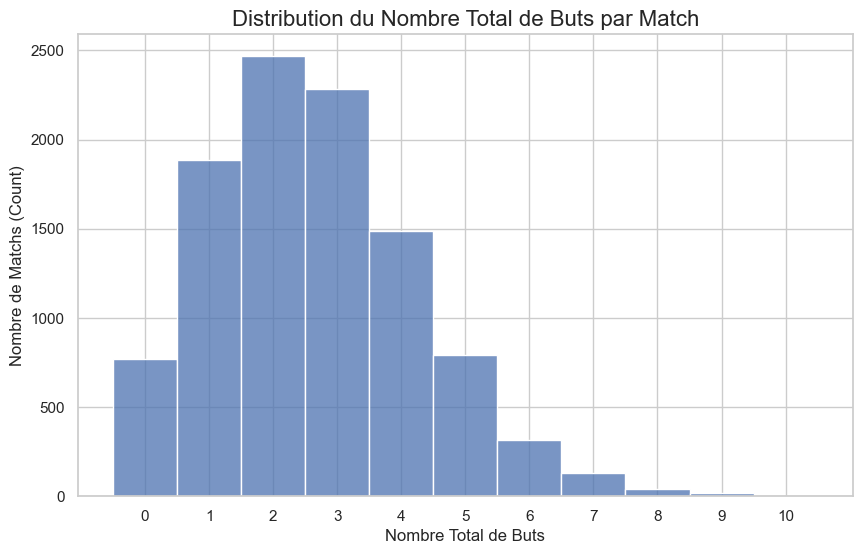

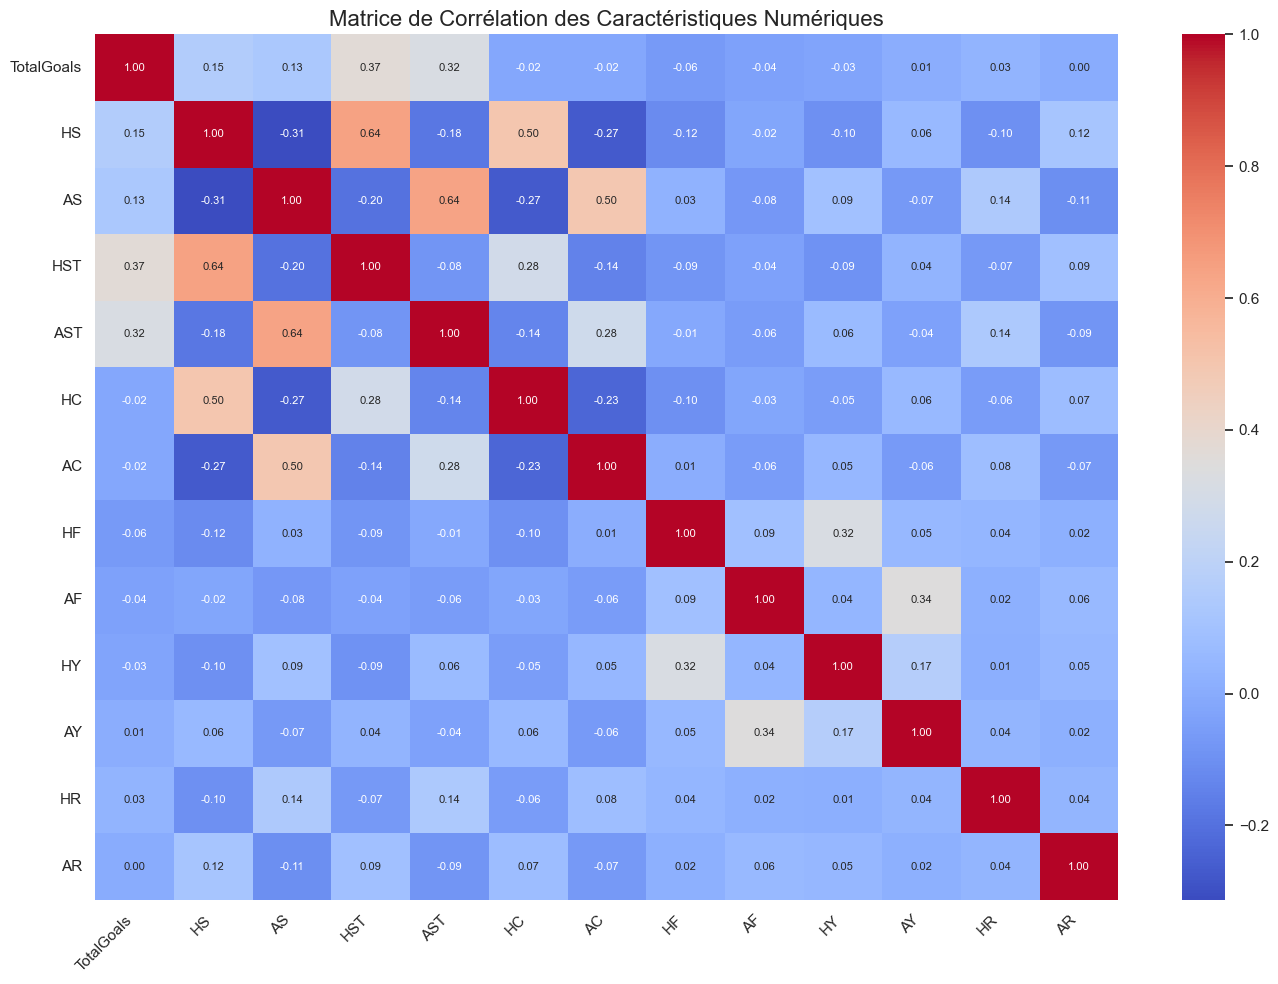

In [10]:
# Visualisation 1 : Distribution de la variable cible (Histogramme seul)
plt.figure(figsize=(10, 6))
max_goals = int(df['TotalGoals'].max())
sns.histplot(df['TotalGoals'], 
             kde=False, 
             bins=range(0, max_goals + 2), # Bins discrets pour les buts
             discrete=True) # Assure que les barres sont centrées sur les entiers

plt.title('Distribution du Nombre Total de Buts par Match', fontsize=16)
plt.xlabel('Nombre Total de Buts', fontsize=12)
plt.ylabel('Nombre de Matchs (Count)', fontsize=12)
plt.xticks(range(0, max_goals + 1, 1))
plt.show()

# Visualisation 2 : Matrice de Corrélation
plt.figure(figsize=(14, 10))
numeric_features_corr = ['TotalGoals', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF', 'HY', 'AY', 'HR', 'AR']
cols_exist = [col for col in numeric_features_corr if col in df.columns]
corr_matrix = df[cols_exist].dropna().corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 8})
plt.title('Matrice de Corrélation des Caractéristiques Numériques', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Réduction des features (on enlève les features de nombre de buts fin de match et mi-temps sinon la prédiction est trop facile) et séparation données train et test

In [20]:
# Définition de la cible (y) et des features (X)
features_to_drop = [
    'id', 'Date', 'Referee', 'Country',            
    'FTHG', 'FTAG', 'FTR',    # Fuite de données (Résultats finaux)
    'HTHG', 'HTAG', 'HTR',    # Fuite de données (Résultats mi-temps)
    'TotalGoals'              # Cible
]

X = df.drop(columns=features_to_drop, errors='ignore')
y = df['TotalGoals']

# Identification des types de colonnes
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Caractéristiques numériques ({len(numeric_features)}) : {numeric_features}")
print(f"Caractéristiques catégorielles ({len(categorical_features)}) : {categorical_features}")

# Séparation des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTaille de l'ensemble d'entraînement : {X_train.shape[0]} lignes")
print(f"Taille de l'ensemble de test : {X_test.shape[0]} lignes")

Caractéristiques numériques (12) : ['HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR']
Caractéristiques catégorielles (5) : ['League', 'Div', 'Season', 'HomeTeam', 'AwayTeam']

Taille de l'ensemble d'entraînement : 8154 lignes
Taille de l'ensemble de test : 2039 lignes


Création pipelines (LinearRegression et RandomForest) avec les données numériques uniquement donc sans prendre en compte les équipes mais uniquement des stats de matchs

In [21]:
# Pipeline pour les données numériques
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Préprocesseur 1 : Numérique seulement (on ignore les autres)
preprocessor_num_only = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ],
    remainder='drop' # Ignorer les colonnes catégorielles
)

# Pipeline 1a : Régression Linéaire (Numérique)
pipeline_lr_num = Pipeline(steps=[
    ('preprocessor', preprocessor_num_only),
    ('model', LinearRegression())
])

# Pipeline 1b : Random Forest (Numérique)
pipeline_rf_num = Pipeline(steps=[
    ('preprocessor', preprocessor_num_only),
    ('model', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))
])

print("Pipelines 'Numérique Uniquement' (LinearRegression, RandomForest) créés.")

Pipelines 'Numérique Uniquement' (LinearRegression, RandomForest) créés.


Entraînement et évaluation simple modèles numérique uniquement

In [22]:
results_list = [] # Liste pour stocker les résultats

# Régression Linéaire
print("Entraînement : Régression Linéaire (Numérique)...")
pipeline_lr_num.fit(X_train, y_train)
y_pred_lr_num = pipeline_lr_num.predict(X_test)
mae_lr_num = mean_absolute_error(y_test, y_pred_lr_num)
r2_lr_num = r2_score(y_test, y_pred_lr_num)
print(f"  -> MAE (LR, Num): {mae_lr_num:.4f} | R2 Score: {r2_lr_num:.4f}")
results_list.append(['Linear Regression', 'Numérique', mae_lr_num, r2_lr_num])

# Random Forest
print("Entraînement : Random Forest (Numérique)...")
pipeline_rf_num.fit(X_train, y_train)
y_pred_rf_num = pipeline_rf_num.predict(X_test)
mae_rf_num = mean_absolute_error(y_test, y_pred_rf_num)
r2_rf_num = r2_score(y_test, y_pred_rf_num)
print(f"  -> MAE (RF, Num): {mae_rf_num:.4f} | R2 Score: {r2_rf_num:.4f}")
results_list.append(['Random Forest', 'Numérique', mae_rf_num, r2_rf_num])

Entraînement : Régression Linéaire (Numérique)...
  -> MAE (LR, Num): 1.0994 | R2 Score: 0.2720
Entraînement : Random Forest (Numérique)...
  -> MAE (RF, Num): 1.0985 | R2 Score: 0.2738


Création pipelines (LinearRegression et RandomForest) avec toutes les données

In [23]:
# Pipeline pour les données catégorielles
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Préprocesseur 2 : Numérique ET Catégoriel
preprocessor_full = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

# Pipeline 2a : Régression Linéaire (Full)
pipeline_lr_full = Pipeline(steps=[
    ('preprocessor', preprocessor_full),
    ('model', LinearRegression())
])

# Pipeline 2b : Random Forest (Full)
pipeline_rf_full = Pipeline(steps=[
    ('preprocessor', preprocessor_full),
    ('model', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))
])

print("Pipelines 'Numérique + Catégoriel' (LinearRegression, RandomForest) créés.")

Pipelines 'Numérique + Catégoriel' (LinearRegression, RandomForest) créés.


Entraînement et évaluation simple modèles complets (numérique + catégoriel)

In [24]:
# Régression Linéaire
print("Entraînement : Régression Linéaire (Full)...")
pipeline_lr_full.fit(X_train, y_train)
y_pred_lr_full = pipeline_lr_full.predict(X_test)
mae_lr_full = mean_absolute_error(y_test, y_pred_lr_full)
r2_lr_full = r2_score(y_test, y_pred_lr_full)
print(f"  -> MAE (LR, Full): {mae_lr_full:.4f} | R2 Score: {r2_lr_full:.4f}")
results_list.append(['Linear Regression', 'Num + Catégoriel', mae_lr_full, r2_lr_full])

# Random Forest
print("Entraînement : Random Forest (Full)...")
pipeline_rf_full.fit(X_train, y_train)
y_pred_rf_full = pipeline_rf_full.predict(X_test)
mae_rf_full = mean_absolute_error(y_test, y_pred_rf_full)
r2_rf_full = r2_score(y_test, y_pred_rf_full)
print(f"  -> MAE (RF, Full): {mae_rf_full:.4f} | R2 Score: {r2_rf_full:.4f}")
results_list.append(['Random Forest', 'Num + Catégoriel', mae_rf_full, r2_rf_full])

Entraînement : Régression Linéaire (Full)...
  -> MAE (LR, Full): 1.0841 | R2 Score: 0.2967
Entraînement : Random Forest (Full)...
  -> MAE (RF, Full): 1.0932 | R2 Score: 0.2869


In [25]:
# Créer un DataFrame pour comparer les résultats
results_df = pd.DataFrame(
    results_list, 
    columns=['Modèle', 'Features', 'MAE', 'R2 Score']
)

# Trier par R2 Score (meilleur en premier)
results_df = results_df.sort_values(by='R2 Score', ascending=False)

print("Tableau comparatif des performances des modèles :")
# L'affichage de 'results_df' dans un notebook sera bien formaté
results_df

Tableau comparatif des performances des modèles :


,Modèle,Features,MAE,R2 Score
2,Linear Regression,Num + Catégoriel,1.084053,0.296653
3,Random Forest,Num + Catégoriel,1.093233,0.286852
1,Random Forest,Numérique,1.098468,0.273847
0,Linear Regression,Numérique,1.099363,0.271983


Le modèle de régression linéaire est mauvais avec des performances particulièrement mauvaises avec toutes les données. Le meilleur est le RandomForest avec toutes les données.
Mais cela reste très moyen. 
Le premier problème peut être du au fait que la régression linéaire a explosé parce que le OneHotEncoder a créé trop de colonnes (57 pour HomeTeam, 57 pour AwayTeam, etc.). Le modèle est submergé par cette haute dimensionnalité et surapprend massivement (overfitting).

Regression Linéaire améliorée

In [26]:
from sklearn.linear_model import Ridge, ElasticNet

# --- Entraînement et évaluation : Modèles Régularisés ---

# 1. Régression Ridge (Bonne alternative par défaut)

print("Entraînement : Régression Ridge (Full)...")
pipeline_ridge_full = Pipeline(steps=[
    ('preprocessor', preprocessor_full),
    ('model', Ridge(alpha=1.0)) 
])

pipeline_ridge_full.fit(X_train, y_train)
y_pred_ridge_full = pipeline_ridge_full.predict(X_test)

mae_ridge_full = mean_absolute_error(y_test, y_pred_ridge_full)
r2_ridge_full = r2_score(y_test, y_pred_ridge_full)

print(f"  -> MAE (Ridge, Full): {mae_ridge_full:.4f} | R2 Score: {r2_ridge_full:.4f}")
results_list.append(['Ridge Regression', 'Num + Catégoriel', mae_ridge_full, r2_ridge_full])


# 2. ElasticNet (Combinaison de L1 et L2)
print("\nEntraînement : ElasticNet (Full)...")
pipeline_elastic_full = Pipeline(steps=[
    ('preprocessor', preprocessor_full),
    ('model', ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42)) 
])

pipeline_elastic_full.fit(X_train, y_train)
y_pred_elastic_full = pipeline_elastic_full.predict(X_test)

mae_elastic_full = mean_absolute_error(y_test, y_pred_elastic_full)
r2_elastic_full = r2_score(y_test, y_pred_elastic_full)

print(f"  -> MAE (ElasticNet, Full): {mae_elastic_full:.4f} | R2 Score: {r2_elastic_full:.4f}")
results_list.append(['ElasticNet', 'Num + Catégoriel', mae_elastic_full, r2_elastic_full])


# --- Afficher le nouveau tableau de résultats ---
print("\n--- Tableau comparatif mis à jour ---")
results_df = pd.DataFrame(
    results_list, 
    columns=['Modèle', 'Features', 'MAE', 'R2 Score']
)
results_df = results_df.sort_values(by='R2 Score', ascending=False)
results_df

Entraînement : Régression Ridge (Full)...
  -> MAE (Ridge, Full): 1.0837 | R2 Score: 0.2972

Entraînement : ElasticNet (Full)...
  -> MAE (ElasticNet, Full): 1.3032 | R2 Score: 0.0326

--- Tableau comparatif mis à jour ---


,Modèle,Features,MAE,R2 Score
4,Ridge Regression,Num + Catégoriel,1.083688,0.297209
2,Linear Regression,Num + Catégoriel,1.084053,0.296653
3,Random Forest,Num + Catégoriel,1.093233,0.286852
1,Random Forest,Numérique,1.098468,0.273847
0,Linear Regression,Numérique,1.099363,0.271983
5,ElasticNet,Num + Catégoriel,1.303193,0.032592


On a pris pour RandomForest maxdeph=10. Regardons si c'est le meilleur paramètre

Démarrage de l'optimisation du RandomForest 


c:\Users\Maxime Philippon\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2881: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Optimisation terminée.

--- Résultats (RandomForest) ---
Meilleur score R2 (validation) : 0.2759
Profondeur optimale (max_depth) trouvée : 8


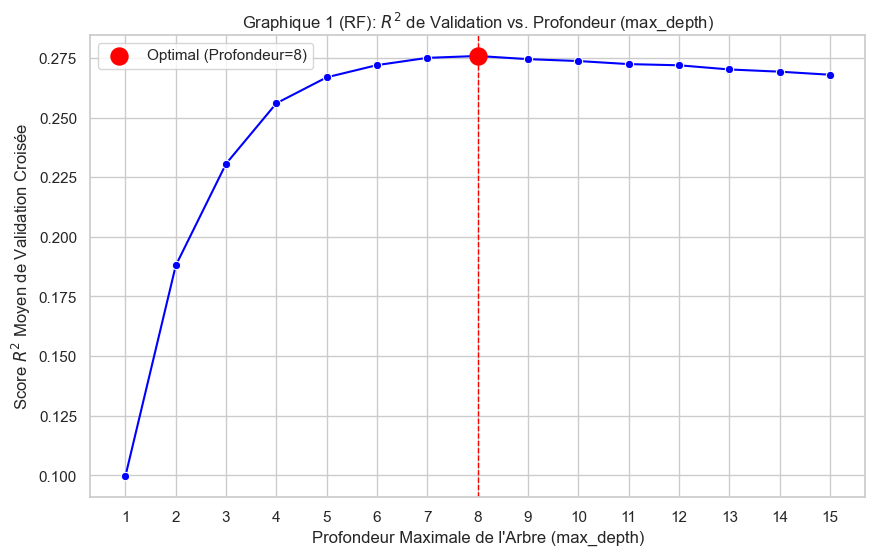

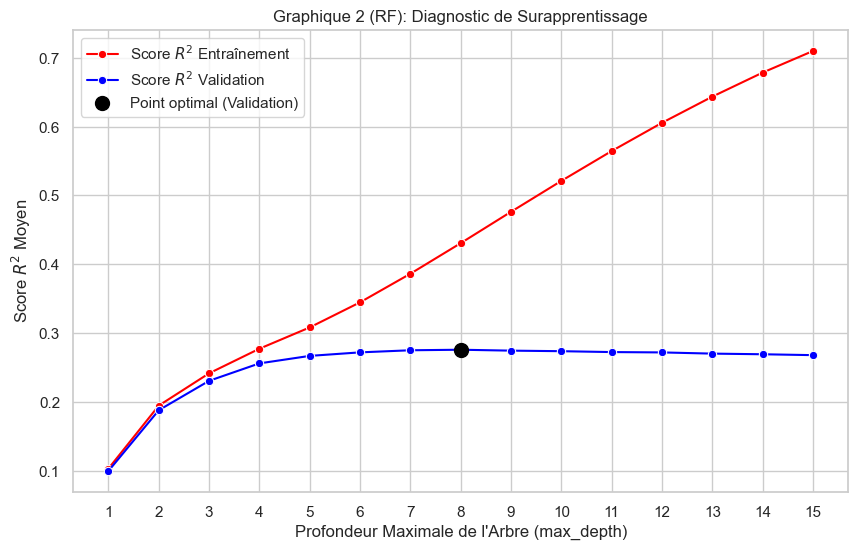

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor 
from sklearn.pipeline import Pipeline 

#  Définir la grille de recherche pour le RandomForest

param_grid_rf = {
    'model__max_depth': np.arange(1, 16)
}

grid_search_rf = GridSearchCV(
    estimator=pipeline_rf_full,  # Utilise pipeline complet
    param_grid=param_grid_rf,
    scoring='r2',
    cv=10, 
    n_jobs=2,
    return_train_score=True  
)

# Entraîner le Grid Search
print("Démarrage de l'optimisation du RandomForest ")

grid_search_rf.fit(X_train, y_train)
print("Optimisation terminée.")


results_rf = pd.DataFrame(grid_search_rf.cv_results_)

# Créer des colonnes faciles à utiliser pour les graphiques
results_rf['max_depth'] = results_rf['param_model__max_depth']
results_rf['mean_valid_r2'] = results_rf['mean_test_score']
results_rf['mean_train_r2'] = results_rf['mean_train_score']

# Déterminer le point optimal
optimal_depth_rf = grid_search_rf.best_params_['model__max_depth']
best_valid_score_rf = grid_search_rf.best_score_

print(f"\n--- Résultats (RandomForest) ---")
print(f"Meilleur score R2 (validation) : {best_valid_score_rf:.4f}")
print(f"Profondeur optimale (max_depth) trouvée : {optimal_depth_rf}")


# --- GRAPHIQUE 1 : R2 de Validation (Généralisation) ---
plt.figure(figsize=(10, 6))
sns.lineplot(
    x='max_depth',
    y='mean_valid_r2',
    data=results_rf,
    marker='o',
    color='blue'
)
plt.scatter(optimal_depth_rf, best_valid_score_rf, color='red', s=150, zorder=5, 
            label=f'Optimal (Profondeur={optimal_depth_rf})')
plt.axvline(x=optimal_depth_rf, color='red', linestyle='--', linewidth=1)

plt.title('Graphique 1 (RF): $R^2$ de Validation vs. Profondeur (max_depth)')
plt.xlabel('Profondeur Maximale de l\'Arbre (max_depth)')
plt.ylabel('Score $R^2$ Moyen de Validation Croisée')
plt.xticks(np.arange(1, 16, 1))
plt.legend()
plt.grid(True)
plt.show()


# --- GRAPHIQUE 2 : R2 Entraînement vs. Validation (Diagnostic de Surapprentissage) ---
plt.figure(figsize=(10, 6))
sns.lineplot(
    x='max_depth',
    y='mean_train_r2',
    data=results_rf,
    marker='o',
    color='red',
    label='Score $R^2$ Entraînement'
)
sns.lineplot(
    x='max_depth',
    y='mean_valid_r2',
    data=results_rf,
    marker='o',
    color='blue',
    label='Score $R^2$ Validation'
)
plt.scatter(optimal_depth_rf, best_valid_score_rf, color='black', s=100, zorder=5, 
            label='Point optimal (Validation)')

plt.title('Graphique 2 (RF): Diagnostic de Surapprentissage')
plt.xlabel('Profondeur Maximale de l\'Arbre (max_depth)')
plt.ylabel('Score $R^2$ Moyen')
plt.xticks(np.arange(1, 16, 1))
plt.legend()
plt.grid(True)
plt.show()

La profondeure optimale était donc la bonne, et on voit que la performence de validation stagne autour de 0.3.


**Création de caractéristiques avec la forme récente**

En effet le niveau des équipes en 2023 n'est pas le même que en 2005 par exemple

In [28]:
import pandas as pd
import numpy as np

# Trier les matchs par date pour que les moyennes glissantes aient un sens

df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values(by='Date')

#  Créer les statistiques de "forme" (par équipe) 

# Créer des dataframes temporaires pour Domicile et Extérieur
df_home = df[['id', 'Date', 'HomeTeam', 'FTHG', 'FTAG']].rename(
    columns={'HomeTeam': 'Team', 'FTHG': 'GoalsScored', 'FTAG': 'GoalsConceded'}
)
df_away = df[['id', 'Date', 'AwayTeam', 'FTAG', 'FTHG']].rename(
    columns={'AwayTeam': 'Team', 'FTAG': 'GoalsScored', 'FTHG': 'GoalsConceded'}
)

# Concaténer en un seul dataframe "long"
df_stats = pd.concat([df_home, df_away]).sort_values(by=['Team', 'Date'])

# --- 3. Calculer les Moyennes Glissantes (Rolling Averages) ---
N_MATCHS = 5 # Nombre de matchs pour la moyenne

# Grouper par équipe et calculer la moyenne glissante
# .shift(1) (ne pas inclure le match actuel)
df_stats['AvgGoalsScored_Last5'] = df_stats.groupby('Team')['GoalsScored'].transform(
    lambda x: x.rolling(N_MATCHS, min_periods=1).mean().shift(1)
)
df_stats['AvgGoalsConceded_Last5'] = df_stats.groupby('Team')['GoalsConceded'].transform(
    lambda x: x.rolling(N_MATCHS, min_periods=1).mean().shift(1)
)

# Remplir les NaNs (le premier match d'une équipe) avec 0
df_stats = df_stats.fillna(0)

# --- 4. Fusionner les stats dans le DataFrame principal ---

# équipes à Domicile
df_stats_home = df_stats.rename(columns={
    'Team': 'HomeTeam',
    'AvgGoalsScored_Last5': 'Home_Avg_Goals_Last_5',
    'AvgGoalsConceded_Last5': 'Home_Avg_Conceded_Last_5'
})
#équipes à l'Extérieur
df_stats_away = df_stats.rename(columns={
    'Team': 'AwayTeam',
    'AvgGoalsScored_Last5': 'Away_Avg_Goals_Last_5',
    'AvgGoalsConceded_Last5': 'Away_Avg_Conceded_Last_5'
})

# Fusionner les stats dans le DataFrame 'df'

df = pd.merge(df, df_stats_home[['id', 'Home_Avg_Goals_Last_5', 'Home_Avg_Conceded_Last_5']], on='id', how='left')
df = pd.merge(df, df_stats_away[['id', 'Away_Avg_Goals_Last_5', 'Away_Avg_Conceded_Last_5']], on='id', how='left')

#Gérer les doublons potentiels si 'id' n'est pas unique ou si les merges créent des problèmes
df = df.drop_duplicates(subset='id')

print(f"Nouvelles colonnes de 'forme' ajoutées (sur les {N_MATCHS} derniers matchs).")

# --- 5. Vérifier le résultat ---
new_features = ['HomeTeam', 'AwayTeam', 'TotalGoals', 'Home_Avg_Goals_Last_5', 'Away_Avg_Conceded_Last_5']
print(df[new_features].tail()) # .tail() est mieux que .head() pour voir des moyennes non nulles

Nouvelles colonnes de 'forme' ajoutées (sur les 5 derniers matchs).
             HomeTeam          AwayTeam  TotalGoals  Home_Avg_Goals_Last_5  \
40752          Wolves           Everton         3.0                    0.8   
40756        Man City  Sheffield United         2.0                    2.6   
40760  Crystal Palace         Brentford         4.0                    0.4   
40764     Aston Villa           Burnley         5.0                    1.8   
40768           Luton           Chelsea         5.0                    2.0   

       Away_Avg_Conceded_Last_5  
40752                       1.8  
40756                       1.8  
40760                       2.2  
40764                       2.2  
40768                       1.8  


Maintenant que c'est trié par date il faut faire un test 

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge  # Utilisation de Ridge (régularisé)
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score



#  Définition X et y 
df['TotalGoals'] = df['FTHG'] + df['FTAG']
features_to_drop = ['id', 'Date', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'TotalGoals']
X = df.drop(columns=features_to_drop, errors='ignore')
y = df['TotalGoals']

# Mise à jour des Listes de Caractéristiques 

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Caractéristiques numériques Mises à Jour (incluant la forme) : {len(numeric_features)}")
print(f"Caractéristiques catégorielles : {len(categorical_features)}")

# Séparation des Données (Train/Test Split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 6. Définition du Préprocesseur (Identique à avant) ---
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor_full = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

# --- 7. Définition des Pipelines de Modèles ---
pipeline_ridge_forme = Pipeline(steps=[
    ('preprocessor', preprocessor_full),
    ('model', Ridge(alpha=1.0))  # Modèle Linéaire régularisé
])

pipeline_rf_forme = Pipeline(steps=[
    ('preprocessor', preprocessor_full),
    ('model', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))
])

# --- 8. Entraînement et Évaluation ---
results_list_new = []

# Test Linéaire (Avec Forme)
print("\nEntraînement : Régression Linéaire (Avec Forme)...")
pipeline_ridge_forme.fit(X_train, y_train)
y_pred_ridge_new = pipeline_ridge_forme.predict(X_test)
mae_ridge_new = mean_absolute_error(y_test, y_pred_ridge_new)
r2_ridge_new = r2_score(y_test, y_pred_ridge_new)
results_list_new.append(['Ridge (Forme)', mae_ridge_new, r2_ridge_new])

# Test Random Forest (Avec Forme)
print("Entraînement : Random Forest (Avec Forme)...")
pipeline_rf_forme.fit(X_train, y_train)
y_pred_rf_new = pipeline_rf_forme.predict(X_test)
mae_rf_new = mean_absolute_error(y_test, y_pred_rf_new)
r2_rf_new = r2_score(y_test, y_pred_rf_new)
results_list_new.append(['Random Forest (Forme)', mae_rf_new, r2_rf_new])

# --- 9. Affichage des Nouveaux Résultats ---
results_df_new = pd.DataFrame(results_list_new, columns=['Modèle', 'MAE', 'R2 Score'])
print("\n--- Nouveaux Résultats (Avec Features de Forme) ---")
print(results_df_new)

Caractéristiques numériques Mises à Jour (incluant la forme) : 16
Caractéristiques catégorielles : 7

Entraînement : Régression Linéaire (Avec Forme)...
Entraînement : Random Forest (Avec Forme)...

--- Nouveaux Résultats (Avec Features de Forme) ---
                  Modèle       MAE  R2 Score
0          Ridge (Forme)  1.098078  0.296332
1  Random Forest (Forme)  1.117181  0.278775


In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Sélection des features
numeric_cols = [
    'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR',
    'Home_Avg_Goals_Last_5', 'Home_Avg_Conceded_Last_5', 
    'Away_Avg_Goals_Last_5', 'Away_Avg_Conceded_Last_5'
]
# On se concentre sur les catégories importantes pour les Embeddings
cat_cols = ['HomeTeam', 'AwayTeam', 'League', 'Season', 'Referee']

# Nettoyage rapide des NaN (s'il en reste)
df_nn = df.copy()
df_nn = df_nn.dropna(subset=numeric_cols + cat_cols + ['TotalGoals'])

# 2. Encodage des Catégories (Label Encoding pour PyTorch Embeddings)
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    # Pour HomeTeam et AwayTeam, on veut le même encodeur pour partager l'embedding
    if col == 'HomeTeam':
        all_teams = pd.concat([df_nn['HomeTeam'], df_nn['AwayTeam']]).unique()
        le.fit(all_teams)
        label_encoders['Team'] = le # On sauve sous 'Team'
        df_nn[col] = le.transform(df_nn[col])
    elif col == 'AwayTeam':
        df_nn[col] = label_encoders['Team'].transform(df_nn[col])
    else:
        df_nn[col] = le.fit_transform(df_nn[col].astype(str))
        label_encoders[col] = le

# 3. Normalisation des données numériques
scaler = StandardScaler()
df_nn[numeric_cols] = scaler.fit_transform(df_nn[numeric_cols])

# 4. Split Train/Test
X_cat = df_nn[cat_cols].values
X_num = df_nn[numeric_cols].values
y = df_nn['TotalGoals'].values

# Conversion en Tensors PyTorch
X_cat_tensor = torch.tensor(X_cat, dtype=torch.long)
X_num_tensor = torch.tensor(X_num, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

# Indices pour le split (80/20)
train_size = int(0.8 * len(df_nn))
X_cat_train, X_cat_test = X_cat_tensor[:train_size], X_cat_tensor[train_size:]
X_num_train, X_num_test = X_num_tensor[:train_size], X_num_tensor[train_size:]
y_train_th, y_test_th = y_tensor[:train_size], y_tensor[train_size:]

print("Données préparées pour PyTorch.")

Données préparées pour PyTorch.


In [31]:
class FootballDataset(Dataset):
    def __init__(self, x_cat, x_num, y):
        self.x_cat = x_cat
        self.x_num = x_num
        self.y = y
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.x_cat[idx], self.x_num[idx], self.y[idx]

# Création des DataLoaders
batch_size = 64
train_dataset = FootballDataset(X_cat_train, X_num_train, y_train_th)
test_dataset = FootballDataset(X_cat_test, X_num_test, y_test_th)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ImprovedGoalPredictorNN(nn.Module):
    def __init__(self, embedding_sizes, n_num_cols, dropout=0.3):
        super(ImprovedGoalPredictorNN, self).__init__()
        
        # --- 1. Couches d'Embeddings (Catégories) ---
        self.embeddings = nn.ModuleList([
            nn.Embedding(categories, size) for categories, size in embedding_sizes
        ])
        self.n_emb = sum(e.embedding_dim for e in self.embeddings)
        
        # --- 2. Couches Denses (Deep Learning) ---
        # Entrée : Embeddings concaténés + Colonnes numériques
        self.input_dim = self.n_emb + n_num_cols
        
        # Séquence de couches : Linear -> BatchNorm -> ReLU -> Dropout
        self.layers = nn.Sequential(
            # Couche 1 : Augmentation de la dimension pour capturer les interactions
            nn.Linear(self.input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            # Couche 2
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            # Couche 3
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout / 2), # Moins de dropout vers la fin
            
            # Couche 4
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            
            # Couche de Sortie (1 neurone pour le nombre de buts)
            nn.Linear(32, 1)
        )

    def forward(self, x_cat, x_num):
        # Traitement des embeddings
        embeddings = []
        for i, e in enumerate(self.embeddings):
            embeddings.append(e(x_cat[:, i]))
        x_cat_emb = torch.cat(embeddings, 1)
        
        # Concaténation avec les données numériques
        x = torch.cat([x_cat_emb, x_num], 1)
        
        # Passage dans le réseau de neurones
        x = self.layers(x)
        
        return x

print("Nouvelle architecture définie.")

Nouvelle architecture définie.


In [33]:
import torch.optim as optim

# 1. Configuration du Device (GPU si dispo)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation du device : {device}")

# 2. Recalcul des dimensions d'embeddings (au cas où)
n_teams = len(label_encoders['Team'].classes_)
n_leagues = len(label_encoders['League'].classes_)
n_seasons = len(label_encoders['Season'].classes_)
n_refs = len(label_encoders['Referee'].classes_)

embedding_sizes = [
    (n_teams, min(50, (n_teams + 1) // 2)),
    (n_teams, min(50, (n_teams + 1) // 2)),
    (n_leagues, min(50, (n_leagues + 1) // 2)),
    (n_seasons, min(50, (n_seasons + 1) // 2)),
    (n_refs, min(50, (n_refs + 1) // 2))
]

# 3. Instanciation du Modèle
model = ImprovedGoalPredictorNN(embedding_sizes, n_num_cols=len(numeric_cols))
model.to(device)

# 4. Fonction de Coût et Optimiseur
# AMÉLIORATION #3 : Utilisation de L1Loss (MAE) au lieu de MSE
criterion = nn.L1Loss() 

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

print("Modèle instancié avec L1Loss.")

Utilisation du device : cpu
Modèle instancié avec L1Loss.


In [34]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import copy

# --- Configuration de l'entraînement ---
epochs = 100  
patience = 10 
best_val_loss = float('inf')
counter = 0
best_model_wts = copy.deepcopy(model.state_dict())

# AMÉLIORATION #2a : Scheduler
# CORRECTION : Suppression de 'verbose=True' pour éviter l'erreur de version
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print("Début de l'entraînement...")

for epoch in range(epochs):
    # --- Phase d'Entraînement ---
    model.train()
    train_losses = []
    
    for cat_data, num_data, targets in train_loader:
        cat_data, num_data, targets = cat_data.to(device), num_data.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(cat_data, num_data)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        
    avg_train_loss = np.mean(train_losses)
    
    # --- Phase de Validation ---
    model.eval()
    val_losses = []
    val_preds = []
    val_targets = []
    
    with torch.no_grad():
        for cat_data, num_data, targets in test_loader:
            cat_data, num_data, targets = cat_data.to(device), num_data.to(device), targets.to(device)
            
            outputs = model(cat_data, num_data)
            loss = criterion(outputs, targets)
            val_losses.append(loss.item())
            
            val_preds.extend(outputs.cpu().numpy())
            val_targets.extend(targets.cpu().numpy())
    
    avg_val_loss = np.mean(val_losses)
    
    # Mise à jour du Scheduler
    scheduler.step(avg_val_loss)
    
    # --- Logging et Early Stopping ---
    val_r2 = r2_score(val_targets, val_preds)
    
    # Récupération manuelle du Learning Rate actuel pour l'affichage
    current_lr = optimizer.param_groups[0]['lr']
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Train MAE: {avg_train_loss:.4f} | Val MAE: {avg_val_loss:.4f} | Val R2: {val_r2:.4f} | LR: {current_lr:.6f}")
    
    # AMÉLIORATION #2b : Early Stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        counter = 0 
    else:
        counter += 1
        if counter >= patience:
            print(f"\n>>> Early Stopping activé à l'époque {epoch+1}. Pas d'amélioration depuis {patience} époques.")
            break

# --- Fin de l'entraînement ---
print("\nChargement des meilleurs poids...")
model.load_state_dict(best_model_wts)

# Évaluation Finale
model.eval()
with torch.no_grad():
    all_preds = []
    all_targets = []
    for cat_data, num_data, targets in test_loader:
        cat_data, num_data = cat_data.to(device), num_data.to(device)
        outputs = model(cat_data, num_data)
        all_preds.extend(outputs.cpu().numpy())
        all_targets.extend(targets.numpy())

final_mae = mean_absolute_error(all_targets, all_preds)
final_r2 = r2_score(all_targets, all_preds)

print(f"--- RÉSULTATS FINAUX (Modèle Amélioré) ---")
print(f"MAE : {final_mae:.4f}")
print(f"R2  : {final_r2:.4f}")

Début de l'entraînement...
Epoch 5/100 | Train MAE: 1.1018 | Val MAE: 1.1311 | Val R2: 0.2215 | LR: 0.001000
Epoch 10/100 | Train MAE: 1.0358 | Val MAE: 1.1364 | Val R2: 0.2201 | LR: 0.001000
Epoch 15/100 | Train MAE: 0.9789 | Val MAE: 1.1384 | Val R2: 0.2178 | LR: 0.000500

>>> Early Stopping activé à l'époque 17. Pas d'amélioration depuis 10 époques.

Chargement des meilleurs poids...
--- RÉSULTATS FINAUX (Modèle Amélioré) ---
MAE : 1.1310
R2  : 0.2174


In [35]:
import pandas as pd
import torch

# 1. Mettre le modèle en mode évaluation (désactive le dropout, etc.)
model.eval()

# Nombre d'exemples à afficher
num_samples = 5

# 2. Faire les prédictions
with torch.no_grad():
    # Récupérer les données du test set (les n premiers exemples)
    # On s'assure d'envoyer sur le bon device (CPU ou GPU) comme lors de l'entraînement
    sample_cat = X_cat_test[:num_samples].to(device)
    sample_num = X_num_test[:num_samples].to(device)
    
    # Vraies valeurs (Actual)
    actuals = y_test_th[:num_samples].cpu().numpy().flatten()
    
    # Prédictions du modèle
    # .cpu() pour ramener les données sur le processeur pour l'affichage, .numpy() pour Pandas
    predictions = model(sample_cat, sample_num).cpu().numpy().flatten()

# 3. Décoder les noms d'équipes pour l'affichage
# On utilise l'encodeur 'Team' sauvegardé lors de la préparation des données
# Rappel: col 0 = HomeTeam, col 1 = AwayTeam dans X_cat
try:
    home_indices = sample_cat[:, 0].cpu().numpy()
    away_indices = sample_cat[:, 1].cpu().numpy()
    
    home_names = label_encoders['Team'].inverse_transform(home_indices)
    away_names = label_encoders['Team'].inverse_transform(away_indices)
except Exception as e:
    print(f"Attention: Impossible de décoder les noms ({e}). Affichage des IDs.")
    home_names = home_indices
    away_names = away_indices

# 4. Création d'un DataFrame pour visualiser
comparison_df = pd.DataFrame({
    'Home Team': home_names,
    'Away Team': away_names,
    'Real Goals': actuals,
    'Predicted': predictions.round(2),
    'Diff (Abs)': abs(actuals - predictions).round(2)
})

# Affichage
print(f"--- Comparaison sur les {num_samples} premiers matchs du Test Set ---")
# Option d'affichage pour voir toutes les colonnes
pd.set_option('display.max_rows', num_samples)
print(comparison_df)

# Petite stat locale
print(f"\nErreur moyenne sur cet échantillon : {comparison_df['Diff (Abs)'].mean():.2f} buts")

--- Comparaison sur les 5 premiers matchs du Test Set ---
    Home Team  Away Team  Real Goals  Predicted  Diff (Abs)
0     Arsenal    Norwich         1.0       2.19        1.19
1   Brentford   Brighton         1.0       1.12        0.12
2   Leicester   Man City         1.0       3.20        2.20
3   West Brom   Millwall         2.0       1.18        0.82
4  Man United  Newcastle         5.0       3.12        1.88

Erreur moyenne sur cet échantillon : 1.24 buts


In [36]:
import pandas as pd
import numpy as np

# --- Sélection du modèle et des données ---
model_to_show = pipeline_ridge_forme  # Votre modèle entraîné
num_samples = 5                       # Nombre de matchs à afficher

# --- 1. Faire les prédictions sur les n premiers exemples du test set ---
X_sample = X_test.iloc[:num_samples].copy() # On prend les 5 premières lignes
y_true_sample = y_test.iloc[:num_samples].values # Les vrais scores

y_pred_sample = model_to_show.predict(X_sample) # Les prédictions

# --- 2. Création d'un petit tableau pour l'affichage ---
results_simple = pd.DataFrame({
    'Home Team': X_sample['HomeTeam'],
    'Away Team': X_sample['AwayTeam'],
    'Vrais Buts': y_true_sample,
    'Prédits': np.round(y_pred_sample, 2) # Arrondi pour plus de clarté
})

# --- 3. Affichage ---
print(f"--- Résultats pour les {num_samples} premiers matchs du Test Set ---")
print(results_simple)

--- Résultats pour les 5 premiers matchs du Test Set ---
            Home Team         Away Team  Vrais Buts  Prédits
26544           Luton         Brentford         3.0     3.15
14968         Cardiff           Preston         2.0     2.12
20456         Reading  Sheffield United         2.0     1.90
26020  Crystal Palace  Sheffield United         1.0     1.89
40284        West Ham       Aston Villa         2.0     2.71


Passage à une classification multiclass

In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Définir une limite max pour les classes (ex: 5+ buts)
MAX_GOALS_CLASS = 5

def categorize_goals(goals):
    # On s'assure de traiter un scalaire (nombre) et non un array
    return int(min(goals, MAX_GOALS_CLASS))

# 2. Créer les nouvelles cibles de classification
# CORRECTION : On s'assure que 'y' est traité comme une Série Pandas pour utiliser .apply()
# Si 'y' est un tableau numpy (ce qui est le cas après PyTorch), on le convertit.
if isinstance(y, np.ndarray):
    y_series = pd.Series(y.flatten()) # .flatten() pour s'assurer qu'il est 1D
else:
    y_series = y

y_class = y_series.apply(categorize_goals)

# Vérification de la distribution des classes
print("Distribution des classes (Nombre de buts) :")
print(y_class.value_counts(normalize=True).sort_index())

# 3. Nouveau Split Train/Test pour la classification
# X reste le même (features numériques + catégorielles)
# Attention : X doit être un DataFrame ici. Si X a été converti en Tensor ou Array, on reprend le DataFrame.
# Si X est un array numpy à ce stade, le code suivant fonctionnera quand même, 
# mais on perd les noms de colonnes. Pour être sûr, on peut reprendre df si dispo.

# Si X est un DataFrame, tout va bien. Sinon, vérifiez vos variables.
X_train, X_test, y_train_class, y_test_class = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

print(f"\nDonnées prêtes. Classes possibles : {sorted(y_class.unique())} (où {MAX_GOALS_CLASS} signifie {MAX_GOALS_CLASS}+ buts)")

Distribution des classes (Nombre de buts) :
0    0.075346
1    0.184833
       ...   
4    0.145983
5    0.127735
Name: proportion, Length: 6, dtype: float64

Données prêtes. Classes possibles : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)] (où 5 signifie 5+ buts)


In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# --- Modèle 1 : Régression Logistique (Multinomial) ---
# Idéal pour avoir des probabilités bien calibrées
pipeline_logreg = Pipeline(steps=[
    ('preprocessor', preprocessor_full),
    ('classifier', LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000))
])

# --- Modèle 2 : Random Forest Classifier ---
# Capable de capturer des motifs non-linéaires complexes
pipeline_rf_class = Pipeline(steps=[
    ('preprocessor', preprocessor_full),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
])

# Liste des modèles à entraîner
models_class = [
    ("Régression Logistique", pipeline_logreg),
    ("Random Forest Class.", pipeline_rf_class)
]

results_class = []

print("Démarrage de l'entraînement des classifieurs...\n")

for name, model in models_class:
    print(f"Entraînement : {name}...")
    model.fit(X_train, y_train_class)
    
    # Prédiction
    y_pred_class = model.predict(X_test)
    
    # Évaluation : Accuracy (Précision globale)
    acc = accuracy_score(y_test_class, y_pred_class)
    print(f"  -> Accuracy : {acc:.4f} ({acc*100:.2f}%)")
    
    results_class.append({
        'Modèle': name,
        'Accuracy': acc,
        'Predictions': y_pred_class # On garde pour analyse détaillée
    })

print("\nEntraînement terminé.")

Démarrage de l'entraînement des classifieurs...

Entraînement : Régression Logistique...


c:\Users\Maxime Philippon\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  -> Accuracy : 0.2972 (29.72%)
Entraînement : Random Forest Class....
  -> Accuracy : 0.2756 (27.56%)

Entraînement terminé.


--- Rapport détaillé pour : Régression Logistique ---

              precision    recall  f1-score   support

           0       0.33      0.14      0.20       154
           1       0.31      0.32      0.32       377
           2       0.29      0.39      0.33       493
           3       0.28      0.31      0.29       457
           4       0.20      0.11      0.14       298
           5       0.39      0.37      0.38       260

    accuracy                           0.30      2039
   macro avg       0.30      0.27      0.28      2039
weighted avg       0.29      0.30      0.29      2039



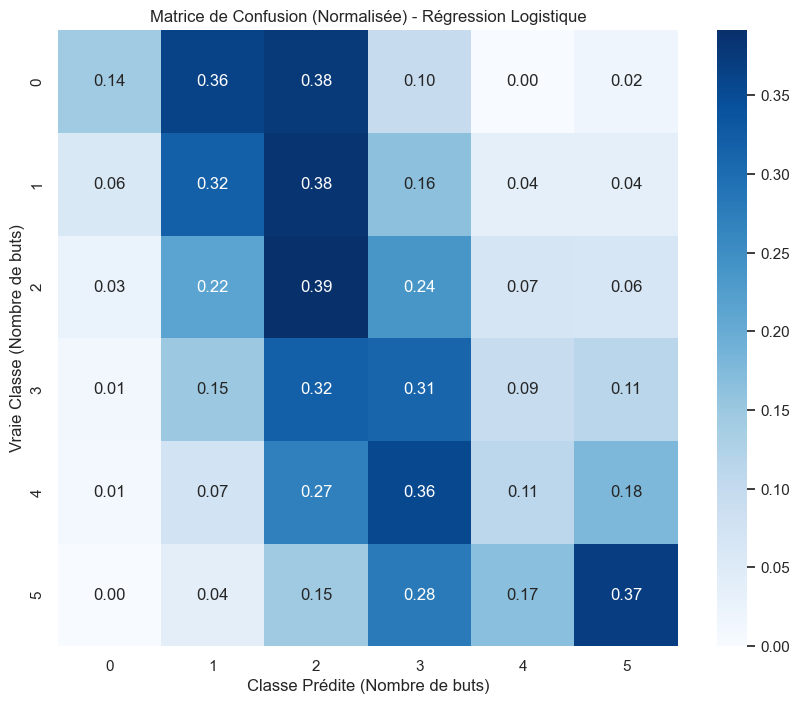


--- Exemple de Probabilités prédites pour 5 matchs ---
   Prob 0 Buts  Prob 1 Buts  Prob 2 Buts  Prob 3 Buts  Prob 4 Buts  \
0         0.00         0.02         0.08         0.16         0.26   
1         0.34         0.36         0.16         0.08         0.05   
2         0.01         0.10         0.27         0.49         0.08   
3         0.00         0.01         0.08         0.14         0.28   
4         0.13         0.26         0.35         0.19         0.07   

   Prob 5+ Buts  Vrai Score  
0          0.48           5  
1          0.01           1  
2          0.05           4  
3          0.49           4  
4          0.01           3  


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Récupérer le meilleur modèle
best_model_name = results_class[0]['Modèle'] # Changez l'index si besoin
y_pred_best = results_class[0]['Predictions']

# 1. Afficher le rapport de classification complet
print(f"--- Rapport détaillé pour : {best_model_name} ---\n")
print(classification_report(y_test_class, y_pred_best, zero_division=0))

# 2. Visualiser la Matrice de Confusion
cm = confusion_matrix(y_test_class, y_pred_best)
# Normaliser par ligne (pour voir les % de réussite par classe réelle)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=range(MAX_GOALS_CLASS + 1),
            yticklabels=range(MAX_GOALS_CLASS + 1))

plt.title(f'Matrice de Confusion (Normalisée) - {best_model_name}')
plt.xlabel('Classe Prédite (Nombre de buts)')
plt.ylabel('Vraie Classe (Nombre de buts)')
plt.show()

# 3. Exemple de Probabilités (Ce qui intéresse les parieurs)
# On prend quelques matchs au hasard
model_instance = models_class[0][1] # Le pipeline entraîné
probas = model_instance.predict_proba(X_test[:5])

print("\n--- Exemple de Probabilités prédites pour 5 matchs ---")
cols_proba = [f"Prob {i} Buts" for i in range(MAX_GOALS_CLASS)] + [f"Prob {MAX_GOALS_CLASS}+ Buts"]
df_probas = pd.DataFrame(probas, columns=cols_proba)
df_probas['Vrai Score'] = y_test_class[:5].values
print(df_probas.round(2))

Globalement si l'on regarde l'accuracy du modèle de régression logistique qui est égale environ à 0.3, on peut se dire que le modèle est intéressant puisque en utilisant le hasard complet on devrait avoir une précision d'environ 0.16 (1 chance sur 6). De plus, en regardant la matrice de confusion on voit bien que le modèle prédit en général des résultats assez proche du nombre de buts réel en prédisant plus souvent 2 ou 3 buts qui sont le nombre de buts trouvés le plus fréquemment sur notre dataset. On remarque aussi que le modèle arrive bien à prédire lorsqu'il y a plus de 5 buts ce qui montre qu'il n'est pas juste meilleur en prédisant plus souvent 2 ou 3 buts.

In [40]:
import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Configuration des classes
MAX_GOALS_CLASS = 5
num_classes = MAX_GOALS_CLASS + 1  # Classes 0, 1, 2, 3, 4, 5 (donc 6 classes)

# 2. Recréation de la cible 'y_class' (au cas où elle aurait été écrasée)
# On s'assure d'utiliser le DataFrame original 'df' nettoyé
numeric_cols = [
    'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR',
    'Home_Avg_Goals_Last_5', 'Home_Avg_Conceded_Last_5', 
    'Away_Avg_Goals_Last_5', 'Away_Avg_Conceded_Last_5'
]
cat_cols = ['HomeTeam', 'AwayTeam', 'League', 'Season', 'Referee']

# Copie propre
df_nn_class = df.copy().dropna(subset=numeric_cols + cat_cols + ['TotalGoals'])

# Création des classes (Capping à 5)
y_raw = df_nn_class['TotalGoals'].values
y_class_data = np.clip(y_raw, 0, MAX_GOALS_CLASS).astype(int)

# 3. Encodage des Catégories (Pour les Embeddings)
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    if col == 'HomeTeam':
        all_teams = pd.concat([df_nn_class['HomeTeam'], df_nn_class['AwayTeam']]).unique()
        le.fit(all_teams.astype(str))
        label_encoders['Team'] = le
        df_nn_class[col] = le.transform(df_nn_class[col].astype(str))
    elif col == 'AwayTeam':
        df_nn_class[col] = label_encoders['Team'].transform(df_nn_class[col].astype(str))
    else:
        df_nn_class[col] = le.fit_transform(df_nn_class[col].astype(str))
        label_encoders[col] = le

# 4. Normalisation Numérique
scaler = StandardScaler()
X_num_data = scaler.fit_transform(df_nn_class[numeric_cols])
X_cat_data = df_nn_class[cat_cols].values

# 5. Split Train/Test (80/20)
# On utilise les mêmes proportions pour comparer
train_size = int(0.8 * len(df_nn_class))

# Conversion en Tenseurs
# Note: Pour CrossEntropyLoss, y doit être un LongTensor (entiers) 1D
X_cat_train = torch.tensor(X_cat_data[:train_size], dtype=torch.long)
X_num_train = torch.tensor(X_num_data[:train_size], dtype=torch.float32)
y_train_torch = torch.tensor(y_class_data[:train_size], dtype=torch.long)

X_cat_test = torch.tensor(X_cat_data[train_size:], dtype=torch.long)
X_num_test = torch.tensor(X_num_data[train_size:], dtype=torch.float32)
y_test_torch = torch.tensor(y_class_data[train_size:], dtype=torch.long)

print(f"Données de classification prêtes. Nombre de classes : {num_classes}")

Données de classification prêtes. Nombre de classes : 6


In [41]:
import torch.nn as nn

class GoalClassifierNN(nn.Module):
    def __init__(self, embedding_sizes, n_num_cols, n_classes, dropout=0.3):
        super(GoalClassifierNN, self).__init__()
        
        # Embeddings
        self.embeddings = nn.ModuleList([
            nn.Embedding(categories, size) for categories, size in embedding_sizes
        ])
        self.n_emb = sum(e.embedding_dim for e in self.embeddings)
        
        # Couches Denses
        self.input_dim = self.n_emb + n_num_cols
        
        self.layers = nn.Sequential(
            nn.Linear(self.input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            
            # Couche de sortie : n_classes neurones (pour prédire les probas de chaque classe)
            nn.Linear(64, n_classes) 
        )

    def forward(self, x_cat, x_num):
        embeddings = []
        for i, e in enumerate(self.embeddings):
            embeddings.append(e(x_cat[:, i]))
        x = torch.cat(embeddings + [x_num], 1)
        x = self.layers(x)
        return x # On retourne les "logits" (les probas brutes avant Softmax)

# Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Calcul tailles embeddings
cats_dims = [len(le.classes_) for le in [label_encoders['Team'], label_encoders['Team'], label_encoders['League'], label_encoders['Season'], label_encoders['Referee']]]
emb_sizes = [(c, min(50, (c + 1) // 2)) for c in cats_dims]

# Instanciation
model_classif = GoalClassifierNN(
    emb_sizes, 
    n_num_cols=len(numeric_cols), 
    n_classes=num_classes
)
model_classif.to(device)
print(model_classif)

GoalClassifierNN(
  (embeddings): ModuleList(
    (0-1): 2 x Embedding(57, 29)
    (2): Embedding(2, 1)
    (3): Embedding(12, 6)
    (4): Embedding(128, 50)
  )
  (layers): Sequential(
    (0): Linear(in_features=131, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=64, out_features=6, bias=True)
  )
)


In [42]:
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Dataloaders
batch_size = 64
train_ds = TensorDataset(X_cat_train, X_num_train, y_train_torch)
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

# Perte et Optimiseur
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_classif.parameters(), lr=0.001)

epochs = 30 # Ajustable
print("Démarrage de l'entraînement du classifieur NN...")

for epoch in range(epochs):
    model_classif.train()
    train_loss = 0.0
    correct = 0
    total = 0
    
    for x_c, x_n, y in train_dl:
        x_c, x_n, y = x_c.to(device), x_n.to(device), y.to(device)
        
        optimizer.zero_grad()
        outputs = model_classif(x_c, x_n) # Sortie = [Batch, 6 classes]
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
        # Calcul précision (Accuracy) pendant l'entraînement
        _, predicted = torch.max(outputs.data, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()
        
    if (epoch+1) % 5 == 0:
        acc = 100 * correct / total
        print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss/len(train_dl):.4f} | Train Acc: {acc:.2f}%")

print("Entraînement terminé.")

Démarrage de l'entraînement du classifieur NN...
Epoch 5/30 | Loss: 1.5282 | Train Acc: 34.03%
Epoch 10/30 | Loss: 1.4342 | Train Acc: 38.41%
Epoch 15/30 | Loss: 1.3503 | Train Acc: 44.03%
Epoch 20/30 | Loss: 1.2657 | Train Acc: 48.10%
Epoch 25/30 | Loss: 1.1896 | Train Acc: 51.40%
Epoch 30/30 | Loss: 1.1345 | Train Acc: 54.80%
Entraînement terminé.


In [43]:
from sklearn.metrics import accuracy_score, classification_report

# 1. Évaluation du Réseau de Neurones
model_classif.eval()
with torch.no_grad():
    # Prédictions (Logits)
    outputs = model_classif(X_cat_test.to(device), X_num_test.to(device))
    # On prend l'indice de la plus haute probabilité comme classe prédite
    _, preds_nn_class = torch.max(outputs, 1)
    
    preds_nn_class = preds_nn_class.cpu().numpy()
    actuals_class = y_test_torch.cpu().numpy()

# Calcul de l'Accuracy
nn_accuracy = accuracy_score(actuals_class, preds_nn_class)

# 2. Récupération du meilleur modèle précédent
# On cherche dans la liste 'results_class' créée précédemment
try:
    # Trie la liste des résultats précédents par Accuracy décroissante
    sorted_results = sorted(results_class, key=lambda x: x['Accuracy'], reverse=True)
    best_prev_model = sorted_results[0]
    best_prev_name = best_prev_model['Modèle']
    best_prev_acc = best_prev_model['Accuracy']
except NameError:
    print("Attention: 'results_class' introuvable. Comparaison impossible.")
    best_prev_name = "Inconnu"
    best_prev_acc = 0.0

# 3. Affichage du Duel
comparison_df = pd.DataFrame({
    'Modèle': [best_prev_name, 'Réseau de Neurones (Classif.)'],
    'Accuracy': [best_prev_acc, nn_accuracy],
    'Différence': [0.0, nn_accuracy - best_prev_acc]
})

print("\n--- DUEL FINAL : Classification Multiclasse ---")
print(comparison_df.sort_values(by='Accuracy', ascending=False))

print(f"\n--- Rapport de Classification (Neural Network) ---")
print(classification_report(actuals_class, preds_nn_class, zero_division=0))

if nn_accuracy > best_prev_acc:
    print(f"Le Réseau de Neurones bat le {best_prev_name} de {(nn_accuracy - best_prev_acc)*100:.2f}% points !")
else:
    print(f" Le {best_prev_name} reste meilleur que le Réseau de Neurones.")


--- DUEL FINAL : Classification Multiclasse ---
                          Modèle  Accuracy  Différence
0          Régression Logistique  0.297205    0.000000
1  Réseau de Neurones (Classif.)  0.278077   -0.019127

--- Rapport de Classification (Neural Network) ---
              precision    recall  f1-score   support

           0       0.21      0.24      0.22       140
           1       0.28      0.27      0.27       386
           2       0.26      0.23      0.25       488
           3       0.26      0.30      0.28       450
           4       0.26      0.18      0.21       295
           5       0.37      0.46      0.41       280

    accuracy                           0.28      2039
   macro avg       0.27      0.28      0.27      2039
weighted avg       0.27      0.28      0.27      2039

 Le Régression Logistique reste meilleur que le Réseau de Neurones.


Ajout de features et tentative de prédiction plus réaliste : prédiction du nombre de buts en seconde mi-temps ou du résultat final en ne connaissant que les stats de la première

In [36]:
data = pd.read_csv('England_football_data.csv', sep=';')
data.head(5)

,id,Country,League,Div,Season,Date,HomeTeam,AwayTeam,Referee,FTHG,...,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
0,0,England,Premier League,E0,2012-2013,2012-08-18 00:00:00,Arsenal,Sunderland,C Foy,0.0,...,4.0,2.0,12.0,8.0,7.0,0.0,0.0,0.0,0.0,0.0
1,1,England,Premier League,E0,2012-2013,2012-08-18 00:00:00,Fulham,Norwich,M Oliver,5.0,...,9.0,2.0,12.0,11.0,6.0,3.0,0.0,0.0,0.0,0.0
2,2,England,Premier League,E0,2012-2013,2012-08-18 00:00:00,Newcastle,Tottenham,M Atkinson,2.0,...,4.0,6.0,12.0,8.0,3.0,5.0,2.0,2.0,0.0,0.0
3,3,England,Premier League,E0,2012-2013,2012-08-18 00:00:00,QPR,Swansea,L Probert,0.0,...,11.0,8.0,11.0,14.0,5.0,3.0,2.0,2.0,0.0,0.0
4,4,England,Premier League,E0,2012-2013,2012-08-18 00:00:00,Reading,Stoke,K Friend,1.0,...,3.0,3.0,9.0,14.0,4.0,3.0,2.0,4.0,0.0,1.0


Création features sur le match (première et deuxième mi-temps)

In [37]:
# Renaming Columns
data.rename(columns={'HTHG': 'FHHG', 'HTAG': 'FHAG', 'HTR': 'FHR'}, inplace=True)

# total goals
data['SHHG'] = data['FTHG'] - data['FHHG']  # 2nd half home goals #
data['SHAG'] = data['FTAG'] - data['FHAG']  # 2nd half away goals #
data['FHTG'] = data['FHHG'] + data['FHAG']  # 1st half total goals #
data['SHTG'] = data['SHHG'] + data['SHAG']  # 2nd half total goals #
data['FTTG'] = data['FTHG'] + data['FTAG']  # full-time total goals
data['FHGD'] = abs(data['FHHG'] - data['FHAG'])  # 1st half goal difference

print('Sample of data:')
data[['FHHG', 'FHAG' ,'SHHG', 'SHAG', 'FHTG', 'SHTG', 'FTTG', 'FHGD']].head()

Sample of data:


,FHHG,FHAG,SHHG,SHAG,FHTG,SHTG,FTTG,FHGD
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,0.0,3.0,0.0,2.0,3.0,5.0,2.0
2,0.0,0.0,2.0,1.0,0.0,3.0,3.0,0.0
3,0.0,1.0,0.0,4.0,1.0,4.0,5.0,1.0
4,0.0,1.0,1.0,0.0,1.0,1.0,2.0,1.0


Création features statistiques équipe et ligues sur la saison

In [38]:
# totals
# RTLM : Running Total League Matches
data['RTLM'] = data.groupby(['League', 'Season']).cumcount() + 1

# RTLG : Running Total League Goals
data['RTLG'] = data.groupby(['League', 'Season'])['FTTG'].cumsum()-data['FTTG']

# 'RTHG' : Running Total Home Goals
data['RTHG'] = data.groupby(['League', 'Season'])['FTHG'].cumsum()-data['FTHG']

# 'RTAG' : Running Total Away Goals
data['RTAG'] = data.groupby(['League', 'Season'])['FTAG'].cumsum()-data['FTAG']

# cumulativ averages
# CALG : Cumulative Average League Goals
data['CALG'] = (data['RTLG'] / (data['RTLM']-1)).fillna(0)
# data.groupby(['League', 'Season'])['FTTG'].transform(lambda x: x.expanding(min_periods=1).mean().shift()).fillna(0)

# AGSH = FTHG / RTLM : Average Goals Scored by Home Team per Match
data['AGSH'] = (data['RTHG'] / (data['RTLM']-1)).fillna(0)

# AGSA = FTAG / RTLM : Average Goals Scored by Away Team per Match
data['AGSA'] = (data['RTAG'] / (data['RTLM']-1)).fillna(0)

# rolling averages
# RALG : Rolling Average League Goals
data['RALG'] = data.groupby(['League', 'Season'])['FTTG'].transform(lambda x: x.rolling(20, min_periods=1).mean().shift()).fillna(0)

# RALHG : Rolling Average League Home Goals
data['RALHG'] = data.groupby(['League', 'Season'])['FTHG'].transform(lambda x: x.rolling(20, min_periods=1).mean().shift()).fillna(0)

# RALAG : Rolling Average League Away Goals
data['RALAG'] = data.groupby(['League', 'Season'])['FTAG'].transform(lambda x: x.rolling(20, min_periods=1).mean().shift()).fillna(0)


print('data sample:\n')

# Display the updated DataFrame with new columns
data.loc[(data['Season']=='2019-2020')&(data['Div']=='E0'),['League', 'Date', 'FTHG', 'FTAG', 'RTLM', 'RTAG', 'CALG', 'AGSH', 'AGSA', 'RALG', 'RALHG', 'RALAG']].head()

data sample:



,League,Date,FTHG,FTAG,RTLM,RTAG,CALG,AGSH,AGSA,RALG,RALHG,RALAG
2660,Premier League,2019-09-08 00:00:00,4.0,1.0,1,0.0,0.00,0.000000,0.000000,0.00,0.000000,0.000000
2661,Premier League,2019-10-08 00:00:00,0.0,5.0,2,1.0,5.00,4.000000,1.000000,5.00,4.000000,1.000000
2662,Premier League,2019-10-08 00:00:00,1.0,1.0,3,6.0,5.00,2.000000,3.000000,5.00,2.000000,3.000000
2663,Premier League,2019-10-08 00:00:00,3.0,0.0,4,7.0,4.00,1.666667,2.333333,4.00,1.666667,2.333333
2664,Premier League,2019-10-08 00:00:00,0.0,0.0,5,7.0,3.75,2.000000,1.750000,3.75,2.000000,1.750000


Création features de forme des équipes sur la saison et plus historiquement

In [39]:
import pandas as pd
import numpy as np

# Liste de toutes les colonnes que ce script va créer
cols_to_create = [
    'HomePoints_Match', 'AwayPoints_Match', # Temporaires
    'Home_Season_PPG', 'Home_Season_GoalDiff',
    'Away_Season_PPG', 'Away_Season_GoalDiff',
    'Home_Last38_PPG', 'Home_Last38_GS', 'Home_Last38_GC',
    'Away_Last38_PPG', 'Away_Last38_GS', 'Away_Last38_GC',
    'HT_Diff', 'Home_Leading_HT', 'Away_Leading_HT', 'Draw_HT'
]

# On supprime ces colonnes si elles existent déjà dans 'data'
# errors='ignore' permet de ne pas planter si la colonne n'existe pas encore
data = data.drop(columns=cols_to_create, errors='ignore')

# On s'assure que les données sont triées par date
data = data.sort_values(by='Date').copy()

# Fonction utilitaire pour calculer les points d'un match
def calculate_points(row, side):
    if row['FTR'] == 'D':
        return 1
    if side == 'Home' and row['FTR'] == 'H':
        return 3
    if side == 'Away' and row['FTR'] == 'A':
        return 3
    return 0

# Calcul des points obtenus sur chaque match actuel
data['HomePoints_Match'] = data.apply(lambda x: calculate_points(x, 'Home'), axis=1)
data['AwayPoints_Match'] = data.apply(lambda x: calculate_points(x, 'Away'), axis=1)

# Restructuration pour calculs
home_df = data[['Date', 'Season', 'HomeTeam', 'HomePoints_Match', 'FTHG', 'FTAG']].rename(
    columns={'HomeTeam': 'Team', 'HomePoints_Match': 'Points', 'FTHG': 'GS', 'FTAG': 'GC'}
)
away_df = data[['Date', 'Season', 'AwayTeam', 'AwayPoints_Match', 'FTAG', 'FTHG']].rename(
    columns={'AwayTeam': 'Team', 'AwayPoints_Match': 'Points', 'FTAG': 'GS', 'FTHG': 'GC'}
)

# Concaténation
team_stats = pd.concat([home_df, away_df]).sort_values(['Team', 'Date'])

# Calcul des Features "Saison" (Reset chaque année)
team_stats['Cum_Points'] = team_stats.groupby(['Season', 'Team'])['Points'].transform(lambda x: x.shift().expanding().sum())
team_stats['Cum_Games'] = team_stats.groupby(['Season', 'Team'])['Points'].transform(lambda x: x.shift().expanding().count())
team_stats['Cum_GS'] = team_stats.groupby(['Season', 'Team'])['GS'].transform(lambda x: x.shift().expanding().sum())
team_stats['Cum_GC'] = team_stats.groupby(['Season', 'Team'])['GC'].transform(lambda x: x.shift().expanding().sum())

# Métriques Saison
team_stats['Season_PPG'] = team_stats['Cum_Points'] / team_stats['Cum_Games']
team_stats['Season_GoalDiff'] = (team_stats['Cum_GS'] - team_stats['Cum_GC']) / team_stats['Cum_Games']

# Remplissage NaN
team_stats['Season_PPG'] = team_stats['Season_PPG'].fillna(0)
team_stats['Season_GoalDiff'] = team_stats['Season_GoalDiff'].fillna(0)


# Calcul des Features "Long Terme" (Cross-Season)
def rolling_stats(x, window=38):
    return x.shift().rolling(window=window, min_periods=5).mean()

team_stats['LongTerm_PPG'] = team_stats.groupby('Team')['Points'].transform(lambda x: rolling_stats(x))
team_stats['LongTerm_GS'] = team_stats.groupby('Team')['GS'].transform(lambda x: rolling_stats(x))
team_stats['LongTerm_GC'] = team_stats.groupby('Team')['GC'].transform(lambda x: rolling_stats(x))

# Remplissage NaN (Médiane)
cols_long = ['LongTerm_PPG', 'LongTerm_GS', 'LongTerm_GC']
for col in cols_long:
    team_stats[col] = team_stats[col].fillna(team_stats[col].median())


# Fusion (Merge) avec le DataFrame principal
# Merge Home
data = data.merge(team_stats[['Date', 'Team', 'Season_PPG', 'Season_GoalDiff', 'LongTerm_PPG', 'LongTerm_GS', 'LongTerm_GC']], 
                  left_on=['Date', 'HomeTeam'], right_on=['Date', 'Team'], how='left')
data.rename(columns={
    'Season_PPG': 'Home_Season_PPG', 'Season_GoalDiff': 'Home_Season_GoalDiff',
    'LongTerm_PPG': 'Home_Last38_PPG', 'LongTerm_GS': 'Home_Last38_GS', 'LongTerm_GC': 'Home_Last38_GC'
}, inplace=True)
data.drop(columns=['Team'], inplace=True)

# Merge Away
data = data.merge(team_stats[['Date', 'Team', 'Season_PPG', 'Season_GoalDiff', 'LongTerm_PPG', 'LongTerm_GS', 'LongTerm_GC']], 
                  left_on=['Date', 'AwayTeam'], right_on=['Date', 'Team'], how='left')
data.rename(columns={
    'Season_PPG': 'Away_Season_PPG', 'Season_GoalDiff': 'Away_Season_GoalDiff',
    'LongTerm_PPG': 'Away_Last38_PPG', 'LongTerm_GS': 'Away_Last38_GS', 'LongTerm_GC': 'Away_Last38_GC'
}, inplace=True)
data.drop(columns=['Team'], inplace=True)


# Features Mi-Temps (Scenario)
data['HT_Diff'] = data['FHHG'] - data['FHAG']
data['Home_Leading_HT'] = (data['HT_Diff'] > 0).astype(int)
data['Away_Leading_HT'] = (data['HT_Diff'] < 0).astype(int)
data['Draw_HT'] = (data['HT_Diff'] == 0).astype(int)

# Nettoyage final des colonnes temporaires
data.drop(columns=['HomePoints_Match', 'AwayPoints_Match'], inplace=True, errors='ignore')

print(data.columns)

# Display the updated DataFrame with new columns
data.loc[(data['Season']=='2019-2020')&(data['Div']=='E0'),['League', 'Date', 'Home_Season_PPG','Home_Last38_PPG']].head()

Index(['id', 'Country', 'League', 'Div', 'Season', 'Date', 'HomeTeam',
       'AwayTeam', 'Referee', 'FTHG', 'FTAG', 'FTR', 'FHHG', 'FHAG', 'FHR',
       'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR',
       'AR', 'SHHG', 'SHAG', 'FHTG', 'SHTG', 'FTTG', 'FHGD', 'RTLM', 'RTLG',
       'RTHG', 'RTAG', 'CALG', 'AGSH', 'AGSA', 'RALG', 'RALHG', 'RALAG',
       'Home_Season_PPG', 'Home_Season_GoalDiff', 'Home_Last38_PPG',
       'Home_Last38_GS', 'Home_Last38_GC', 'Away_Season_PPG',
       'Away_Season_GoalDiff', 'Away_Last38_PPG', 'Away_Last38_GS',
       'Away_Last38_GC', 'HT_Diff', 'Home_Leading_HT', 'Away_Leading_HT',
       'Draw_HT'],
      dtype='object')


,League,Date,Home_Season_PPG,Home_Last38_PPG
5559,Premier League,2019-01-09 00:00:00,0.0,1.815789
5560,Premier League,2019-01-09 00:00:00,0.0,1.289474
5569,Premier League,2019-01-12 00:00:00,0.0,1.657895
5570,Premier League,2019-01-12 00:00:00,0.0,1.657895
5571,Premier League,2019-01-12 00:00:00,0.0,1.342105


Maintenant qu'on a créé des features permettant une indication du niveau de l'équipe et de sa forme on peut créer un modèle que l'on entraîne et évalue sans les features HomeTeam et AwayTeam.

In [40]:
# Définition de la cible (y) et des features (X)
features_to_drop = [
    'id', 'Date', 'Referee', 'Country', 'HomeTeam', 'AwayTeam',           
    'FTHG', 'FTAG', 'SHHG', 'SHAG', 'SHTG', # features 2nde mi-temps
    'FTTG', 'FTR' # cibles
]

X = data.drop(columns=features_to_drop, errors='ignore')
y1 = data['FTR']
y2 = data['FTTG']

# Identification des types de colonnes
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Caractéristiques numériques ({len(numeric_features)}) : {numeric_features}")
print(f"Caractéristiques catégorielles ({len(categorical_features)}) : {categorical_features}")

# Séparation des données
X_train, X_test, y1_train, y1_test = train_test_split(X, y1, test_size=0.2, random_state=42)
X_train, X_test, y2_train, y2_test = train_test_split(X, y2, test_size=0.2, random_state=42)
print(f"\nTaille de l'ensemble d'entraînement : {X_train.shape[0]} lignes")
print(f"Taille de l'ensemble de test : {X_test.shape[0]} lignes")

Caractéristiques numériques (40) : ['FHHG', 'FHAG', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'FHTG', 'FHGD', 'RTLM', 'RTLG', 'RTHG', 'RTAG', 'CALG', 'AGSH', 'AGSA', 'RALG', 'RALHG', 'RALAG', 'Home_Season_PPG', 'Home_Season_GoalDiff', 'Home_Last38_PPG', 'Home_Last38_GS', 'Home_Last38_GC', 'Away_Season_PPG', 'Away_Season_GoalDiff', 'Away_Last38_PPG', 'Away_Last38_GS', 'Away_Last38_GC', 'HT_Diff', 'Home_Leading_HT', 'Away_Leading_HT', 'Draw_HT']
Caractéristiques catégorielles (4) : ['League', 'Div', 'Season', 'FHR']

Taille de l'ensemble d'entraînement : 8154 lignes
Taille de l'ensemble de test : 2039 lignes


Entraînement d'un premier modèle

Entraînement du modèle Random Forest en cours...
Entraînement terminé.

Accuracy (Précision globale) : 0.6351 (63.51%)

--- Rapport de Classification ---
              precision    recall  f1-score   support

           A       0.66      0.72      0.68       616
           D       0.46      0.28      0.35       553
           H       0.68      0.81      0.74       870

    accuracy                           0.64      2039
   macro avg       0.60      0.60      0.59      2039
weighted avg       0.61      0.64      0.61      2039



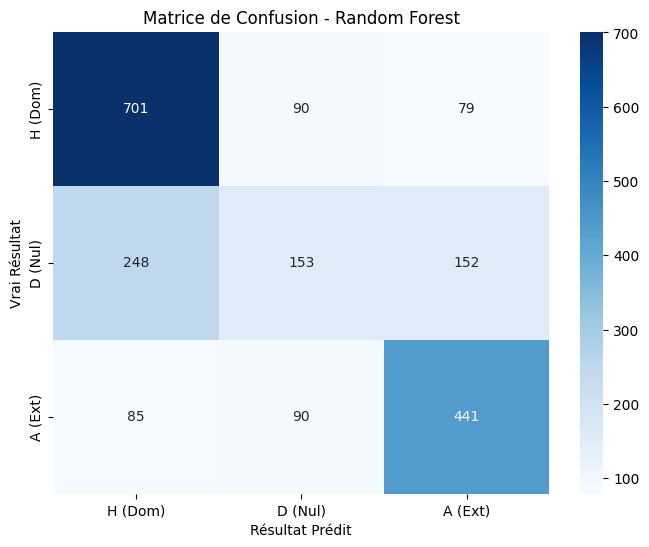

C:\Users\Maxime Philippon\AppData\Local\Temp\ipykernel_6724\3471901715.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis')


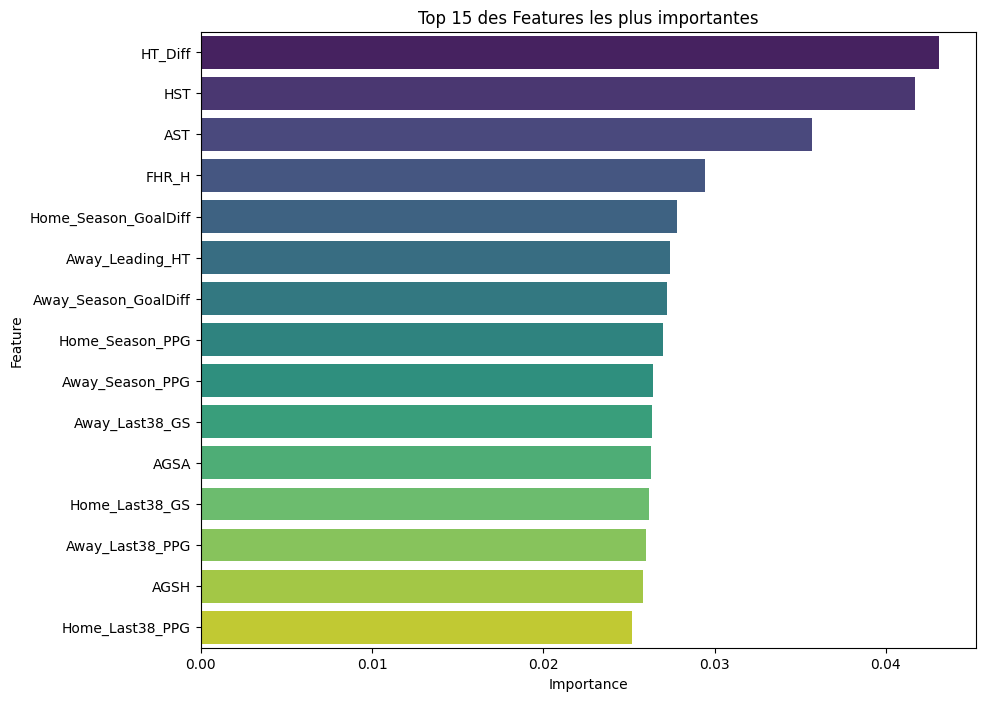

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- 1. Création du Préprocesseur ---
# On doit traiter les colonnes numériques différemment des catégorielles

# Pour les numériques : on remplace les NaN par la médiane et on normalise (StandardScaler)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pour les catégorielles : on remplace les NaN par le plus fréquent et on fait un OneHotEncoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')) # ignore les nouvelles catégories inconnues au test
])

# On combine les deux dans un ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# --- 2. Création du Modèle complet (Pipeline) ---
# On utilise un Random Forest avec 100 arbres
model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

# --- 3. Entraînement ---
print("Entraînement du modèle Random Forest en cours...")
model_rf.fit(X_train, y1_train) # y1 correspond à 'FTR'
print("Entraînement terminé.")

# --- 4. Prédiction et Évaluation ---
y_pred = model_rf.predict(X_test)

# Métriques globales
acc = accuracy_score(y1_test, y_pred)
print(f"\nAccuracy (Précision globale) : {acc:.4f} ({acc*100:.2f}%)")

# Rapport détaillé par classe (H, D, A)
print("\n--- Rapport de Classification ---")
print(classification_report(y1_test, y_pred))

# --- 5. Visualisation de la Matrice de Confusion ---
# Cela permet de voir où le modèle se trompe (ex: confond-il souvent Nul et Victoire Ext ?)
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y1_test, y_pred, labels=['H', 'D', 'A'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['H (Dom)', 'D (Nul)', 'A (Ext)'], 
            yticklabels=['H (Dom)', 'D (Nul)', 'A (Ext)'])
plt.title('Matrice de Confusion - Random Forest')
plt.ylabel('Vrai Résultat')
plt.xlabel('Résultat Prédit')
plt.show()

# --- 6. Importance des Features ---
# Quelles colonnes ont le plus aidé le modèle ?
# On récupère les noms des features après encodage
feature_names = numeric_features + \
    list(model_rf.named_steps['preprocessor'].named_transformers_['cat']
         .named_steps['encoder'].get_feature_names_out(categorical_features))

importances = model_rf.named_steps['classifier'].feature_importances_

# Création d'un DataFrame pour trier
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(15) # Top 15

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis')
plt.title('Top 15 des Features les plus importantes')
plt.show()

On a déjà une relativement bonne prédiction un modèle aléatoire aurait une accuracy d'environ 0.33. On remarque que globalement le modèle a plus de difficulté à prédire les matchs nul.

On essaie maintenant d'entraîner différents types de modèle et on les compare.

In [42]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import pandas as pd

# --- 1. Définition des nouveaux modèles ---

# Gradient Boosting (Similaire à XGBoost)
# Souvent meilleur que le Random Forest pour la précision pure
model_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))
])

# Régression Logistique
# Très rapide et interprétable (donne des probabilités bien calibrées)
model_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42))
])

# SVM (Support Vector Machine)
# Efficace en haute dimension
model_svm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', probability=True, random_state=42))
])

# Liste des modèles à comparer (On rajoute le RF pour avoir tout sous les yeux si besoin)
models = [
    ("Random Forest", model_rf), # Celui que vous avez déjà entraîné
    ("Gradient Boosting", model_gb),
    ("Logistic Regression", model_lr),
    ("SVM", model_svm)
]

# --- 2. Boucle d'entraînement et d'évaluation ---
results = []

print("Début du comparatif...")

for name, model in models:
    print(f"-> Entraînement de : {name}...")
    
    # Entraînement
    model.fit(X_train, y1_train)
    
    # Prédiction
    y_pred_loop = model.predict(X_test)
    
    # Métriques
    acc = accuracy_score(y1_test, y_pred_loop)
    
    # On stocke les résultats
    results.append({
        'Modèle': name,
        'Accuracy': acc,
        'Précision (Macro)': classification_report(y1_test, y_pred_loop, output_dict=True)['macro avg']['precision'],
        'Rappel (Macro)': classification_report(y1_test, y_pred_loop, output_dict=True)['macro avg']['recall']
    })

# --- 3. Affichage du Tableau Comparatif ---
results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)

print("\n--- CLASSEMENT FINAL DES MODÈLES ---")
print(results_df)

# --- 4. Focus sur le meilleur nouveau modèle ---
best_model_name = results_df.iloc[0]['Modèle']
print(f"\nLe meilleur modèle est : {best_model_name}")

# Si le meilleur est le Gradient Boosting, on affiche son rapport détaillé
if best_model_name == "Gradient Boosting":
    print("\n--- Rapport détaillé (Gradient Boosting) ---")
    y_pred_gb = model_gb.predict(X_test)
    print(classification_report(y1_test, y_pred_gb))

Début du comparatif...
-> Entraînement de : Random Forest...
-> Entraînement de : Gradient Boosting...
-> Entraînement de : Logistic Regression...


c:\Users\Maxime Philippon\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


-> Entraînement de : SVM...

--- CLASSEMENT FINAL DES MODÈLES ---
                Modèle  Accuracy  Précision (Macro)  Rappel (Macro)
2  Logistic Regression  0.639039           0.597876        0.603834
0        Random Forest  0.635115           0.597886        0.599443
3                  SVM  0.633644           0.594067        0.596933
1    Gradient Boosting  0.633154           0.592458        0.597120

Le meilleur modèle est : Logistic Regression


Lancement de la Cross-Validation (10-fold) sur 4 modèles...
-> Traitement de : Random Forest... Fait. (Moyenne: 0.6379)
-> Traitement de : Gradient Boosting... Fait. (Moyenne: 0.6494)
-> Traitement de : Logistic Regression... Fait. (Moyenne: 0.6539)
-> Traitement de : SVM... Fait. (Moyenne: 0.6467)

--- RÉSULTATS CROSS-VALIDATION (10 Folds) ---
                Modèle  Accuracy Moyenne  Écart-Type (Std)       Min       Max
2  Logistic Regression          0.653880          0.016151  0.634936  0.686948
1    Gradient Boosting          0.649368          0.013755  0.631011  0.675172
3                  SVM          0.646718          0.012734  0.630392  0.677134
0        Random Forest          0.637887          0.015175  0.616290  0.664377


C:\Users\Maxime Philippon\AppData\Local\Temp\ipykernel_6724\1918097008.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Modèle', y='Accuracy', data=df_details, palette='Set2')


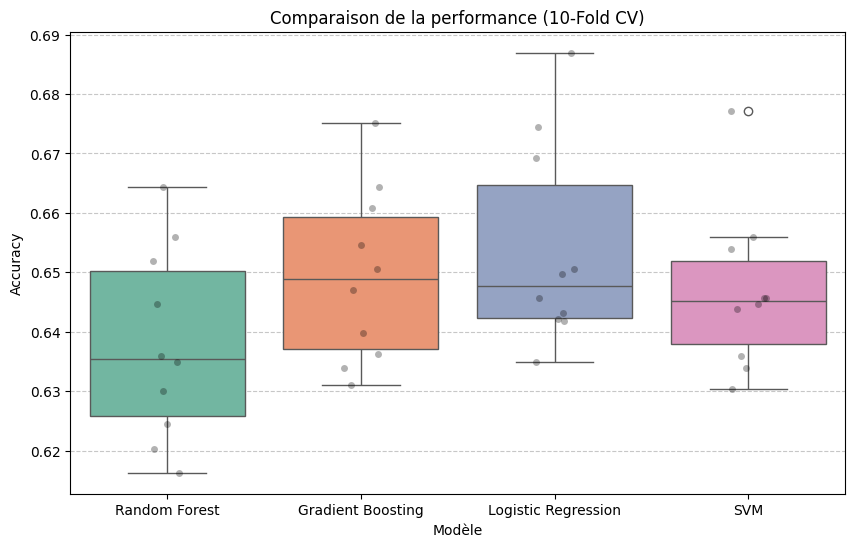

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# --- Configuration de la Cross-Validation ---
# StratifiedKFold assure que chaque "fold" (pli) a la même proportion de H/D/A
# C'est crucial pour le foot où les matchs nuls sont moins fréquents
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_results = []
cv_details = [] # Pour le graphique (boxplot)

print(f"Lancement de la Cross-Validation (10-fold) sur {len(models)} modèles...")

for name, model in models:
    print(f"-> Traitement de : {name}...", end=" ")
    
    # Exécution de la CV
    # On utilise X et y1 (tout le dataset), la CV gère les splits
    # n_jobs=-1 utilise tous les coeurs du processeur pour aller plus vite
    scores = cross_val_score(model, X, y1, cv=cv, scoring='accuracy', n_jobs=-1)
    
    # Stockage des stats
    cv_results.append({
        'Modèle': name,
        'Accuracy Moyenne': scores.mean(),
        'Écart-Type (Std)': scores.std(),
        'Min': scores.min(),
        'Max': scores.max()
    })
    
    # Stockage des scores bruts pour le graphique
    for score in scores:
        cv_details.append({'Modèle': name, 'Accuracy': score})
        
    print(f"Fait. (Moyenne: {scores.mean():.4f})")

# --- Affichage des Résultats ---
df_cv_summary = pd.DataFrame(cv_results).sort_values(by='Accuracy Moyenne', ascending=False)

print("\n--- RÉSULTATS CROSS-VALIDATION (10 Folds) ---")
print(df_cv_summary)

# --- Visualisation (Boxplot) ---
# Le Boxplot est le meilleur moyen de comparer la stabilité
plt.figure(figsize=(10, 6))
df_details = pd.DataFrame(cv_details)

sns.boxplot(x='Modèle', y='Accuracy', data=df_details, palette='Set2')
sns.stripplot(x='Modèle', y='Accuracy', data=df_details, color='black', alpha=0.3) # Montre les points individuels

plt.title('Comparaison de la performance (10-Fold CV)')
plt.ylabel('Accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [44]:
import pandas as pd
from sklearn.model_selection import cross_val_score

# 1. Récupération des scores détaillés par pli (Fold)
# On utilise un dictionnaire pour stocker les 10 scores de chaque modèle
scores_dict = {}

print("Calcul des scores par fold en cours...")

for name, model in models:
    # On récupère le tableau des 10 scores
    scores = cross_val_score(model, X, y1, cv=cv, scoring='accuracy', n_jobs=-1)
    scores_dict[name] = scores

# 2. Transformation en DataFrame
# Chaque ligne représente un Fold (0 à 9), chaque colonne un modèle
df_scores_detail = pd.DataFrame(scores_dict)

# 3. Détermination du vainqueur pour chaque Fold
# idxmax(axis=1) renvoie le nom de la colonne (Modèle) qui a la valeur max sur la ligne
df_scores_detail['Winner'] = df_scores_detail.idxmax(axis=1)

# 4. Comptage des victoires
win_counts = df_scores_detail['Winner'].value_counts()

# --- Affichage des résultats ---

print("\n--- Compteur de victoires (sur 10 Folds) ---")
print(win_counts)

print("\n--- Détail des duels (Scores par Fold) ---")
# On met en évidence le score max de chaque ligne
def highlight_max(s):
    is_max = s == s.max()
    return ['font-weight: bold; background-color: lightgreen' if v else '' for v in is_max]

# Affichage stylisé (fonctionne dans Jupyter)
try:
    display(df_scores_detail.style.apply(highlight_max, axis=1, subset=df_scores_detail.columns[:-1]))
except:
    # Fallback si 'display' n'existe pas (ex: console standard)
    print(df_scores_detail)

Calcul des scores par fold en cours...

--- Compteur de victoires (sur 10 Folds) ---
Winner
Logistic Regression    5
Gradient Boosting      3
SVM                    2
Name: count, dtype: int64

--- Détail des duels (Scores par Fold) ---


,Random Forest,Gradient Boosting,Logistic Regression,SVM,Winner
0,0.651961,0.647059,0.642157,0.653922,SVM
1,0.655882,0.660784,0.674510,0.655882,Logistic Regression
2,0.624510,0.636275,0.643137,0.630392,Logistic Regression
3,0.616290,0.631011,0.645731,0.635918,Logistic Regression
4,0.635918,0.664377,0.669284,0.644750,Logistic Regression
5,0.620216,0.639843,0.634936,0.633955,Gradient Boosting
6,0.664377,0.675172,0.686948,0.677134,Logistic Regression
7,0.630029,0.633955,0.641806,0.645731,SVM
8,0.634936,0.650638,0.650638,0.643768,Gradient Boosting
9,0.644750,0.654563,0.649657,0.645731,Gradient Boosting


On voit que le modèle de régression logistique semble bien être le meilleur en effet il est meilleur sur la moitié des folds et a le deuxième meilleur score sur les folds où il n'est pas meilleur à part sur le premier.

Fine Tuning de la régression logistique

In [45]:
from sklearn.model_selection import GridSearchCV

# 1. Définition de la grille des hyperparamètres à tester
# On teste deux solveurs différents avec leurs pénalités compatibles
param_grid = [
    # Configuration 1 : Solver standard (lbfgs) - ne supporte que L2
    {
        'classifier__solver': ['lbfgs'],
        'classifier__penalty': ['l2'],
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__class_weight': [None, 'balanced'] # 'balanced' aide si une classe (ex: Nul) est rare
    },
    # Configuration 2 : Solver avancé (saga) - supporte L1 et L2
    {
        'classifier__solver': ['saga'],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__class_weight': [None, 'balanced']
    }
]

# 2. Configuration de la recherche (Grid Search)
# cv=5 : On fait une validation croisée à 5 plis pour chaque combinaison (très robuste)
grid_search = GridSearchCV(
    model_lr, # Votre pipeline existant
    param_grid,
    cv=5,
    scoring='accuracy', # On optimise l'Accuracy
    n_jobs=-1, # Utilise tous les coeurs du CPU
    verbose=1
)

print("Recherche des meilleurs hyperparamètres en cours...")
grid_search.fit(X_train, y1_train)

# --- 3. Résultats ---
print(f"\n✅ Meilleurs paramètres trouvés :")
print(grid_search.best_params_)

print(f"\nMeilleure Accuracy (Validation Croisée) : {grid_search.best_score_:.4f}")

# --- 4. Évaluation finale sur le Test Set (qui n'a pas servi à l'optimisation) ---
best_model = grid_search.best_estimator_
final_acc = best_model.score(X_test, y1_test)

print(f"Accuracy Finale sur le Test Set : {final_acc:.4f}")

# Comparaison rapide avec le modèle par défaut
base_acc = model_lr.score(X_test, y1_test) if hasattr(model_lr, 'score') else 0
print(f"Gain par rapport au modèle par défaut : {(final_acc - base_acc)*100:.2f} points")

Recherche des meilleurs hyperparamètres en cours...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Meilleurs paramètres trouvés :
{'classifier__C': 0.1, 'classifier__class_weight': None, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}

Meilleure Accuracy (Validation Croisée) : 0.6580
Accuracy Finale sur le Test Set : 0.6415
Gain par rapport au modèle par défaut : 0.25 points


c:\Users\Maxime Philippon\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
